<a href="https://colab.research.google.com/github/faisu6339-glitch/Real_World-Projects/blob/main/Cat_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
bhavikjikadara_dog_and_cat_classification_dataset_path = kagglehub.dataset_download('bhavikjikadara/dog-and-cat-classification-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/7981.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/6234.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/1269.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/3863.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/6241.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/10304.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/623.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/2193.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/11925.jpg
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/3750.jpg
/kaggle/input/datasets/bhavikjikadara/d

In [ ]:
import os

print(os.listdir('/kaggle/input/datasets'))

['bhavikjikadara']


In [ ]:
import os

cat_path = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Cat"

dog_path = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog"

print("Cats:", len(os.listdir(cat_path)))
print("Dogs:", len(os.listdir(dog_path)))

Cats: 12499
Dogs: 12499


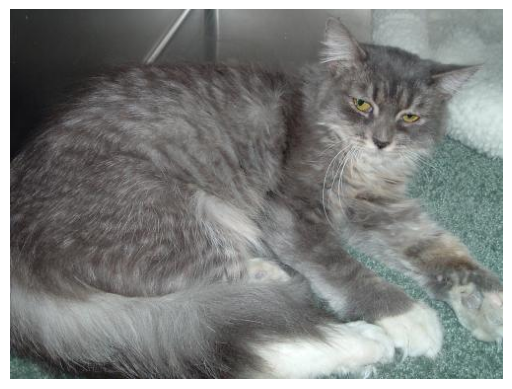

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Cat/11590.jpg"

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE=224
BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_gen = datagen.flow_from_directory(
    "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages",

    target_size=(224,224),
    batch_size=32,
    class_mode='binary',

    subset='training'
)

Found 20000 images belonging to 2 classes.


In [ ]:
val_gen = datagen.flow_from_directory(
    "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages",

    target_size=(224,224),
    batch_size=32,
    class_mode='binary',

    subset='validation',
    shuffle=False
)

Found 4998 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)